# Twitter Data processing

In [1]:
import pandas as pd
import os
import re

In [2]:
tweets = pd.read_csv("../data/raw/twitter/tweets_sentiment.csv",
                     usecols=['date', 'decoded_tweet', 'tweet', 'neg', 'neu', 'pos', 'compound','likes_count', 'retweets_count', 'replies_count', 'search'],
                     low_memory=False)

In [3]:
print(f"shape: {tweets.shape}")
print(f"\ndata types:\n{tweets.dtypes}")
tweets.head(3)

shape: (824908, 11)

data types:
date               object
tweet              object
replies_count       int64
retweets_count      int64
likes_count         int64
search             object
decoded_tweet      object
neg               float64
neu               float64
pos               float64
compound          float64
dtype: object


,date,tweet,replies_count,retweets_count,likes_count,search,decoded_tweet,neg,neu,pos,compound
0,2013-03-29,Bitcoin: The Cyberpunk Cryptocurrency,0,12,18,cryptocurrency,Bitcoin: The Cyberpunk Cryptocurrency http://...,0.0,1.0,0.0,0.0
1,2013-04-15,Bitcoin Isn't the Only Cryptocurrency in Town via,3,34,17,cryptocurrency,Bitcoin Isn't the Only Cryptocurrency in Town ...,0.0,1.0,0.0,0.0
2,2013-04-14,", a ""cryptocurrency"", went on a tear last week...",15,153,61,cryptocurrency,"#Bitcoin, a ""cryptocurrency"", went on a tear l...",0.0,1.0,0.0,0.0


### Convert Dates

In [4]:
tweets['date'] = pd.to_datetime(tweets['date'], errors='coerce')
tweets = tweets.dropna(subset=['date'])
tweets['day'] = tweets['date'].dt.date

print(f"Filtered: {len(tweets)} tweets")
print(f"Date range: {tweets['date'].min().date()} to {tweets['date'].max().date()}")
print(f"\nPer year:")
print(tweets['date'].dt.year.value_counts().sort_index())

Filtered: 824908 tweets
Date range: 2013-01-04 to 2021-02-10

Per year:
date
2013        95
2014      1618
2015      3584
2016      9121
2017     95279
2018    262257
2019    182495
2020    209006
2021     61453
Name: count, dtype: int64


### Extract Fraud Keyword Mentions

In [5]:
# Filter to Ethereum-related tweets only
eth_keywords = ['ethereum', 'eth', 'ether']
eth_pattern = re.compile(r'\b(?:' + '|'.join(map(re.escape, eth_keywords)) + r')\b', re.IGNORECASE)

text_col = tweets['decoded_tweet'].fillna(tweets['tweet']).astype(str).str.lower()

tweets = tweets[(tweets['search'].str.lower() == 'ethereum') | (text_col.str.contains(eth_pattern, na=False))]

print(f"ethereum tweets: {len(tweets)}")


ethereum tweets: 191141


In [6]:
fraud_keywords = [
    # General fraud
    'scam', 'scammer', 'fraud', 'fraudulent', 'fake',
    'malicious', 'suspicious', 'warning',

    # Technical exploits
    'hack', 'hacked', 'hacker', 'exploit', 'exploited',
    'attack', 'breach', 'compromised', 'vulnerability',
    'backdoor',

    # Crypto-specific scams
    'rug pull', 'rugpull', 'rug-pull',
    'honeypot', 'exit scam',
    'phishing', 'phish',
    'ponzi', 'pyramid',

    # Theft indicators
    'stolen', 'theft', 'steal', 'drain', 'drained', 'drainer'
]

fraud_pattern = re.compile(r'\b(?:' + '|'.join(map(re.escape, fraud_keywords)) + r')\b', re.IGNORECASE)
# Use decoded_tweet if available, fall back to tweet
text_col = tweets['decoded_tweet'].fillna(tweets['tweet']).astype(str).str.lower()
tweets['has_fraud_mention'] = text_col.str.contains(fraud_pattern,na=False).astype(int)

print(f"Tweets with fraud keywords: {tweets['has_fraud_mention'].sum()} ({tweets['has_fraud_mention'].mean()*100:.2f}%)")

Tweets with fraud keywords: 2524 (1.32%)


### Explore Sentiment Distribution

In [7]:
print("Sentiment Statistics:")
print(tweets[['neg', 'neu', 'pos', 'compound']].describe().to_string())

print(f"\nSentiment breakdown:")
print(f"Positive (compound > 0.05): {(tweets['compound'] > 0.05).mean():.1%}")
print(f"Neutral (-0.05 to 0.05): {((tweets['compound'] >= -0.05) & (tweets['compound'] <= 0.05)).mean():.1%}")
print(f"Negative (compound < -0.05): {(tweets['compound'] < -0.05).mean():.1%}")

Sentiment Statistics:
                 neg            neu            pos       compound
count  191141.000000  191141.000000  191141.000000  191141.000000
mean        0.024628       0.873094       0.102276       0.302304
std         0.056208       0.111790       0.101178       0.418045
min         0.000000       0.137000       0.000000      -0.998200
25%         0.000000       0.801000       0.000000       0.000000
50%         0.000000       0.884000       0.088000       0.340000
75%         0.000000       1.000000       0.167000       0.669600
max         0.845000       1.000000       0.812000       0.999500

Sentiment breakdown:
Positive (compound > 0.05): 59.7%
Neutral (-0.05 to 0.05): 28.6%
Negative (compound < -0.05): 11.6%


### Daily Aggregation and Feature engineering

In [8]:
twitter_daily = tweets.groupby('day').agg(
    # Volume
    twitter_total_activity=('compound', 'count'),

    # Sentiment - compound score
    twitter_avg_sentiment=('compound', 'mean'),
    twitter_sentiment_std=('compound', 'std'),

    # Sentiment - granular scores
    twitter_avg_negative=('neg', 'mean'),
    twitter_avg_positive=('pos', 'mean'),

    # Sentiment polarity ratio (positive tweets / total non-neutral)
    twitter_negative_ratio=('compound', lambda x: (x < -0.05).mean()),

    # Fraud mentions
    twitter_fraud_mention_ratio=('has_fraud_mention', 'mean'),
    twitter_fraud_mention_count=('has_fraud_mention', 'sum'),

    # Engagement
    twitter_avg_likes=('likes_count', 'mean'),
    twitter_avg_retweets=('retweets_count', 'mean'),
    twitter_avg_replies=('replies_count', 'mean'),
).reset_index()

twitter_daily['day'] = pd.to_datetime(twitter_daily['day'])

# Fill NaN std with 0 (days with 1 tweet)
twitter_daily['twitter_sentiment_std'] = twitter_daily['twitter_sentiment_std'].fillna(0)

# Activity spike: ratio to 7-day rolling mean
twitter_daily['twitter_activity_spike'] = (
    twitter_daily['twitter_total_activity'] /
    twitter_daily['twitter_total_activity'].rolling(7, min_periods=1).mean()
)

# Engagement spike: combined engagement vs rolling avg
twitter_daily['twitter_total_engagement'] = (
    twitter_daily['twitter_avg_likes'] +
    twitter_daily['twitter_avg_retweets'] +
    twitter_daily['twitter_avg_replies']
)

print(f"Daily features: {len(twitter_daily)} days, {len(twitter_daily.columns)} columns")
print(f"\nColumns: {twitter_daily.columns.tolist()}")

Daily features: 2022 days, 14 columns

Columns: ['day', 'twitter_total_activity', 'twitter_avg_sentiment', 'twitter_sentiment_std', 'twitter_avg_negative', 'twitter_avg_positive', 'twitter_negative_ratio', 'twitter_fraud_mention_ratio', 'twitter_fraud_mention_count', 'twitter_avg_likes', 'twitter_avg_retweets', 'twitter_avg_replies', 'twitter_activity_spike', 'twitter_total_engagement']


### Visualize Features

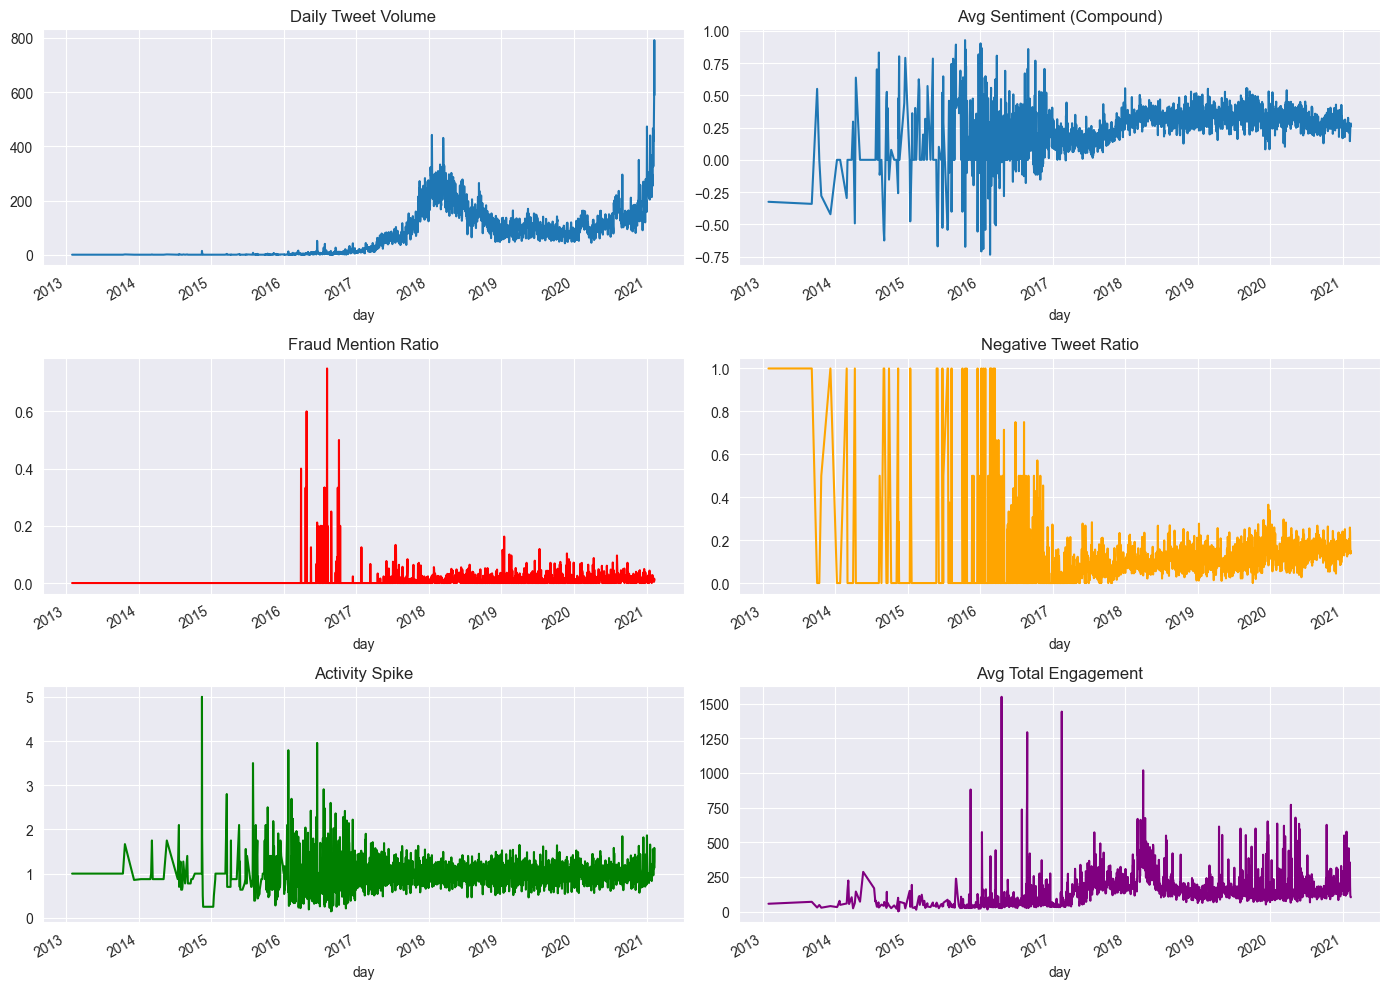

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

twitter_daily.plot(x='day', y='twitter_total_activity', ax=axes[0, 0], title='Daily Tweet Volume', legend=False)
twitter_daily.plot(x='day', y='twitter_avg_sentiment', ax=axes[0, 1], title='Avg Sentiment (Compound)', legend=False)
twitter_daily.plot(x='day', y='twitter_fraud_mention_ratio', ax=axes[1, 0], title='Fraud Mention Ratio', legend=False, color='red')
twitter_daily.plot(x='day', y='twitter_negative_ratio', ax=axes[1, 1], title='Negative Tweet Ratio', legend=False, color='orange')
twitter_daily.plot(x='day', y='twitter_activity_spike', ax=axes[2, 0], title='Activity Spike', legend=False, color='green')
twitter_daily.plot(x='day', y='twitter_total_engagement', ax=axes[2, 1], title='Avg Total Engagement', legend=False, color='purple')

plt.tight_layout()
plt.show()

In [10]:
output_dir = '../data/processed/twitter'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'twitter_daily_cleaned.parquet')
twitter_daily.to_parquet(output_path, index=False)
print("Saved")

Saved
